In [1]:
import pandas as pd

df = pd.read_csv("features_30_sec.csv")  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
np.random.seed(0)
print("Missing value per column:")
print(df.isna().sum())

Missing value per column:
filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean       

In [8]:
features = ["tempo", "chroma_stft_mean", "spectral_centroid_mean", "rms_mean", "rolloff_mean", "mfcc1_mean"]
X = df[features] 
y = df["label"]              
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"Training samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")

Training samples: 700, Test samples: 300


In [16]:
param_grid = {'n_neighbors': list(range(1, 51, 2)),
              'metric':['euclidean', 'manhattan']}
knn = KNeighborsClassifier()

grid_clf = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_clf.fit(X_train_scaled, y_train)  

print(f"Best k: {grid_clf.best_params_['n_neighbors']}")
print(f"Best cross-validation accuracy: {grid_clf.best_score_:.3f}")

test_accuracy = grid_clf.score(X_test_scaled, y_test)
print(f"Test accuracy with best k: {test_accuracy:.3f}")
print(f"Best metric:{grid_clf.best_params_['metric']}")
best_model=grid_clf.best_estimator_
     

Best k: 5
Best cross-validation accuracy: 0.460
Test accuracy with best k: 0.430
Best metric:manhattan


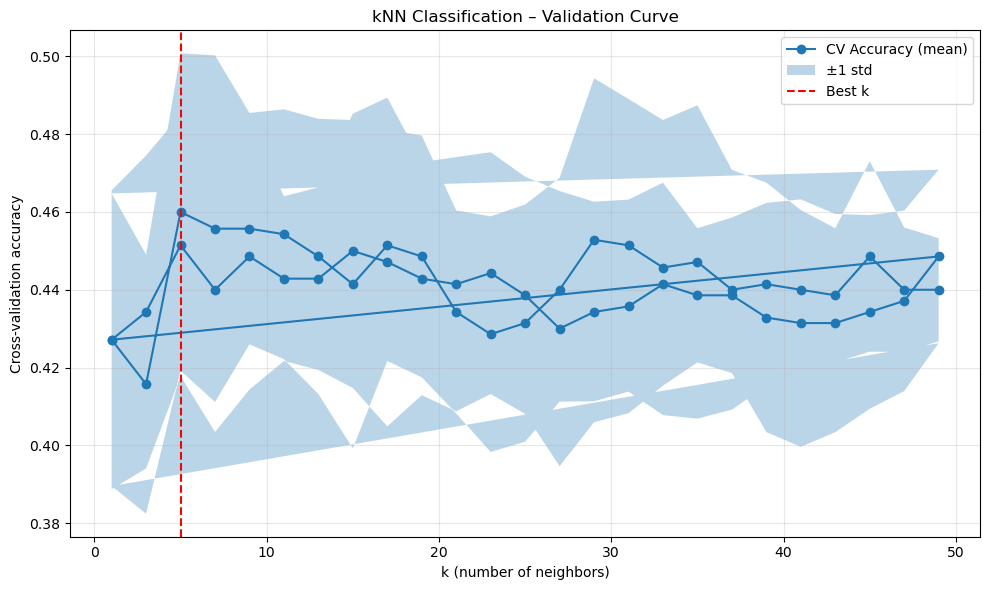

In [18]:
plt.figure(figsize=(10, 6))
results = grid_clf.cv_results_
k_vals = results['param_n_neighbors'].data.astype(int)
mean_scores = results['mean_test_score']
std_scores = results['std_test_score']

plt.plot(k_vals, mean_scores, 'o-', label='CV Accuracy (mean)')
plt.fill_between(k_vals, mean_scores - std_scores, mean_scores + std_scores,
                 alpha=0.3, label='±1 std')
plt.axvline(grid_clf.best_params_['n_neighbors'], color='red',
            linestyle='--', label='Best k')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-validation accuracy')
plt.title('kNN Classification – Validation Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("knn_cv_classification.png", dpi=120);

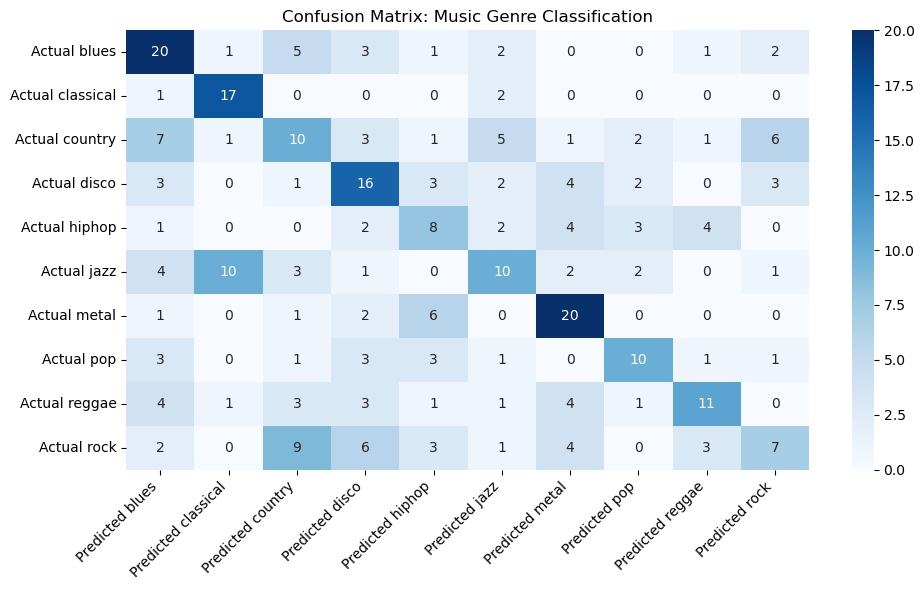

In [27]:

import seaborn as sns
from sklearn.metrics import confusion_matrix


genres = np.unique(df['label'])

actual_labels = [f'Actual {g}' for g in genres]
predicted_labels = [f'Predicted {g}' for g in genres]

y_pred = grid_clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=predicted_labels, 
            yticklabels=actual_labels)

plt.title('Confusion Matrix: Music Genre Classification')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [29]:
joblib.dump(best_model,'music_model.pkl')

['music_model.pkl']